In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

try:
    from sklearn.datasets import fetch_openml
    dataset = fetch_openml(name='bank-marketing', version=1, as_frame=True)
    df = dataset.frame
except:
    data = {
        'Age': [45, 33, 28, 51, 62, 39, 41, 35, 43, 58],
        'Income': [94, 120, 45, 150, 200, 80, 110, 60, 130, 90],
        'Family': [4, 3, 1, 2, 1, 2, 3, 4, 2, 1],
        'Education': [1, 2, 3, 2, 3, 1, 2, 1, 3, 2],
        'Personal Loan': [0, 1, 0, 1, 1, 0, 0, 0, 1, 0]
    }
    df = pd.DataFrame(data)

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


Accuracy Score: 0.8973791883224593


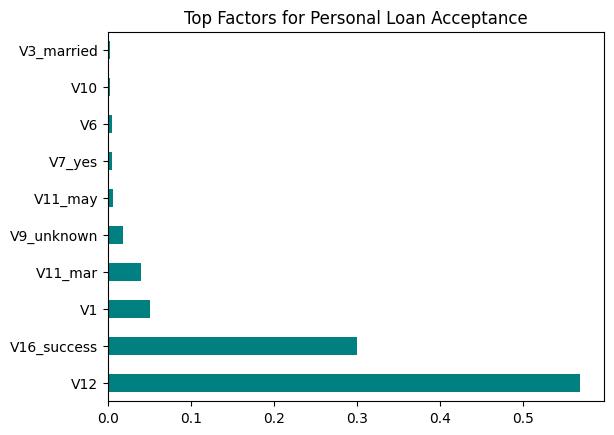

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


df_final = pd.get_dummies(df, drop_first=True)


X = df_final.iloc[:, :-1] 
y = df_final.iloc[:, -1]   


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)


predictions = model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, predictions)}")


importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top Factors for Personal Loan Acceptance')
plt.show()